# 05b — PyCAP Monte Carlo Uncertainty

**Purpose:** Run a first-pass Monte Carlo uncertainty experiment for the Little Plover River PyCAP analytical model.

This notebook builds from:

```text
04_pycap_parameter_perturbation.ipynb
05a_pycap_parameter_perturbation_selected_wells.ipynb
```

The deterministic perturbation notebook changed one input at a time. This notebook samples multiple uncertain inputs together:

```text
T factor  ~ Uniform(0.80, 1.20)
S factor  ~ Uniform(0.80, 1.20)
Q factor  ~ Uniform(0.90, 1.10)
```

where:

- `T` = transmissivity, global project property
- `S` = storage, global project property
- `Q` = pumping rate, applied as a global multiplier to every well

## Important first-pass caveat

This is a **screening-level Monte Carlo workflow**, not a final uncertainty analysis.

The ranges are intentionally simple and transparent. Later, these ranges can be replaced with better distributions based on calibration results, literature, parameter bounds, or expert judgment.


## 1. Imports and project-root setup

In [19]:
from pathlib import Path
import os
import sys
import shutil
from copy import deepcopy
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define project paths

In [20]:
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"

LPR_PYCAP_RAW_DIR = DATA_DIR / "raw" / "lpr_pycap"
LPR_PYCAP_BASE_DIR = LPR_PYCAP_RAW_DIR / "pycap_base"
LPR_PYCAP_BASE_OUTPUT_DIR = LPR_PYCAP_BASE_DIR / "output"

PYCAP_RUN_NAME = "LPR_Redux"
PYCAP_YAML_NAME = f"{PYCAP_RUN_NAME}.yml"
PYCAP_YAML_PATH = LPR_PYCAP_BASE_DIR / PYCAP_YAML_NAME

MC_DIR = PYCAP_RESULTS_DIR / "monte_carlo_uncertainty"
REALIZATIONS_DIR = MC_DIR / "realizations"
TABLES_DIR = MC_DIR / "tables"
FIGURES_DIR = MC_DIR / "figures"

for folder in [MC_DIR, REALIZATIONS_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Baseline YAML:    {PYCAP_YAML_PATH.relative_to(PROJECT_ROOT)}")
print(f"Monte Carlo dir:  {MC_DIR.relative_to(PROJECT_ROOT)}")
print(f"Realizations dir: {REALIZATIONS_DIR.relative_to(PROJECT_ROOT)}")


Baseline YAML:    data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
Monte Carlo dir:  results/pycap_runs/monte_carlo_uncertainty
Realizations dir: results/pycap_runs/monte_carlo_uncertainty/realizations


## 3. Import PyCAP

In [21]:
try:
    import pycap
    from pycap.analysis_project import Project

    print("PyCAP imported successfully.")
    print(f"pycap module: {pycap}")
    print(f"Project class: {Project}")

except Exception as err:
    print("PyCAP import failed.")
    print(type(err).__name__)
    print(err)
    raise


PyCAP imported successfully.
pycap module: <module 'pycap' from '/opt/conda/envs/gw_uncertainty/lib/python3.11/site-packages/pycap/__init__.py'>
Project class: <class 'pycap.analysis_project.Project'>


## 4. Load baseline YAML and define helper functions

In [22]:
with open(PYCAP_YAML_PATH, "r") as f:
    baseline_config = yaml.safe_load(f)

if not isinstance(baseline_config, dict):
    raise TypeError(f"Expected baseline YAML to load as a dictionary, got {type(baseline_config)}")

GPM_TO_CFS = 1 / 7.48052 / 60

def is_likely_well_entry(key, value):
    """Identify likely well entries from the PyCAP YAML."""
    if not isinstance(value, dict):
        return False

    key_text = str(key).lower()
    has_q = "Q" in value or "q" in value
    has_loc = isinstance(value.get("loc"), dict)
    key_says_well = "well" in key_text

    return key_says_well and (has_q or has_loc)


def build_well_inventory(config):
    """Build a simple well table from a PyCAP YAML dictionary."""
    rows = []

    for key, value in config.items():
        if not is_likely_well_entry(key, value):
            continue

        loc = value.get("loc", {})
        q_gpm = value.get("Q", value.get("q", np.nan))
        q_cfs = q_gpm * GPM_TO_CFS if pd.notna(q_gpm) else np.nan

        rows.append(
            {
                "well_key": key,
                "name": value.get("name", key),
                "Q_gpm": q_gpm,
                "Q_cfs": q_cfs,
                "x": loc.get("x", np.nan) if isinstance(loc, dict) else np.nan,
                "y": loc.get("y", np.nan) if isinstance(loc, dict) else np.nan,
            }
        )

    return pd.DataFrame(rows)


def write_yaml(config, yaml_path):
    """Write a PyCAP YAML dictionary to disk."""
    yaml_path.parent.mkdir(parents=True, exist_ok=True)
    with open(yaml_path, "w") as f:
        yaml.safe_dump(config, f, sort_keys=False)


def run_pycap_project(run_dir, yaml_name):
    """Run PyCAP in a realization folder and return timing information."""
    run_dir = Path(run_dir)
    yaml_path = run_dir / yaml_name

    start_time = datetime.now()

    old_cwd = Path.cwd()
    os.chdir(run_dir)

    try:
        ap = Project(yaml_path)
        ap.report_responses()
        ap.write_responses_csv()
    finally:
        os.chdir(old_cwd)

    end_time = datetime.now()
    elapsed = end_time - start_time

    return {
        "start_time": start_time,
        "end_time": end_time,
        "elapsed": elapsed,
    }


def get_output_paths(run_dir):
    """Return expected PyCAP output paths for a realization run folder."""
    output_dir = Path(run_dir) / "output"
    return {
        "report_txt": output_dir / f"{PYCAP_RUN_NAME}.report.txt",
        "table_report": output_dir / f"{PYCAP_RUN_NAME}.table_report.csv",
        "all_ts": output_dir / f"{PYCAP_RUN_NAME}.table_report.all_ts.csv",
        "base_stream_depletion": output_dir / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv",
    }


def compute_depletion_potential(config, base_stream_depletion_path):
    """Compute depletion potential from a YAML dictionary and base stream depletion output table."""
    wells_df = build_well_inventory(config)
    base_stream_depletion = pd.read_csv(base_stream_depletion_path, index_col=0)

    if "LPR" not in base_stream_depletion.columns:
        raise KeyError(
            f"Expected an 'LPR' column in {base_stream_depletion_path.name}. "
            f"Available columns: {list(base_stream_depletion.columns)}"
        )

    depletion_df = base_stream_depletion[["LPR"]].rename(columns={"LPR": "DEPL_cfs"})

    dp_df = wells_df.merge(
        depletion_df,
        left_on="name",
        right_index=True,
        how="left",
    )

    dp_df["Depletion_Potential"] = dp_df["DEPL_cfs"] / dp_df["Q_cfs"]

    return dp_df


def apply_mc_sample(config, T_factor, S_factor, Q_factor):
    """Apply sampled T, S, and global Q factors to a copy of the baseline config."""
    config_new = deepcopy(config)

    props = config_new.get("project_properties", {})

    if "T" not in props:
        raise KeyError("Could not find project_properties['T'] in the YAML.")
    if "S" not in props:
        raise KeyError("Could not find project_properties['S'] in the YAML.")

    props["T"] = props["T"] * T_factor
    props["S"] = props["S"] * S_factor

    n_q_changed = 0
    for key, value in config_new.items():
        if not is_likely_well_entry(key, value):
            continue

        if "Q" in value:
            value["Q"] = value["Q"] * Q_factor
            n_q_changed += 1
        elif "q" in value:
            value["q"] = value["q"] * Q_factor
            n_q_changed += 1

    if n_q_changed == 0:
        raise ValueError("No well pumping values were changed.")

    return config_new


baseline_wells_df = build_well_inventory(baseline_config)

print(f"Loaded baseline YAML with {len(baseline_config)} top-level keys.")
print(f"Number of wells: {len(baseline_wells_df)}")
print(f"Baseline T: {baseline_config['project_properties'].get('T')}")
print(f"Baseline S: {baseline_config['project_properties'].get('S')}")


Loaded baseline YAML with 656 top-level keys.
Number of wells: 327
Baseline T: 1700.0
Baseline S: 0.12


## 5. Build baseline depletion-potential table

In [23]:
baseline_base_stream_path = (
    LPR_PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv"
)

baseline_dp = compute_depletion_potential(
    config=baseline_config,
    base_stream_depletion_path=baseline_base_stream_path,
)

baseline_dp = baseline_dp.sort_values("Depletion_Potential", ascending=False).reset_index(drop=True)

baseline_dp_path = TABLES_DIR / "baseline_depletion_potential.csv"
baseline_dp.to_csv(baseline_dp_path, index=False)

print(f"Saved: {baseline_dp_path.relative_to(PROJECT_ROOT)}")
baseline_dp.head(15)


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/baseline_depletion_potential.csv


,well_key,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential
0,well_23627,23627,276.5,0.616045,89.484380,44.475732,0.345167,0.560296
1,well_68529,68529,219.9,0.489939,89.484333,44.479917,0.274004,0.559261
2,well_23653,23653,263.6,0.587303,89.498433,44.465117,0.326483,0.555901
3,well_466,466,315.9,0.703828,89.493950,44.461175,0.383091,0.544296
4,well_23934,23934,370.6,0.825700,89.477778,44.486112,0.398148,0.482195
5,well_69049,69049,37.6,0.083773,89.475600,44.484350,0.039051,0.466146
6,well_467,467,296.9,0.661496,89.493973,44.458573,0.287480,0.434590
7,well_71109,71109,15.0,0.033420,89.496006,44.485207,0.014082,0.421362
8,well_24323,24323,206.4,0.459861,89.503300,44.464950,0.162236,0.352793
9,well_71110,71110,13.0,0.028964,89.498127,44.484075,0.009220,0.318309


## 6. Define Monte Carlo settings

Start with a small-to-moderate number of realizations so the notebook runs quickly.

After the workflow is stable, you can increase:

```python
N_REALIZATIONS = 100
```

or more.


In [24]:
RANDOM_SEED = 564
N_REALIZATIONS = 100

T_FACTOR_LOW = 0.80
T_FACTOR_HIGH = 1.20

S_FACTOR_LOW = 0.80
S_FACTOR_HIGH = 1.20

Q_FACTOR_LOW = 0.90
Q_FACTOR_HIGH = 1.10

rng = np.random.default_rng(RANDOM_SEED)

samples = pd.DataFrame(
    {
        "realization": [f"mc_{i:03d}" for i in range(N_REALIZATIONS)],
        "T_factor": rng.uniform(T_FACTOR_LOW, T_FACTOR_HIGH, N_REALIZATIONS),
        "S_factor": rng.uniform(S_FACTOR_LOW, S_FACTOR_HIGH, N_REALIZATIONS),
        "Q_factor": rng.uniform(Q_FACTOR_LOW, Q_FACTOR_HIGH, N_REALIZATIONS),
    }
)

samples["T_value"] = baseline_config["project_properties"]["T"] * samples["T_factor"]
samples["S_value"] = baseline_config["project_properties"]["S"] * samples["S_factor"]

samples_path = TABLES_DIR / "monte_carlo_samples.csv"
samples.to_csv(samples_path, index=False)

print(f"Saved: {samples_path.relative_to(PROJECT_ROOT)}")
samples.head()


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_samples.csv


,realization,T_factor,S_factor,Q_factor,T_value,S_value
0,mc_000,1.064683,0.801212,0.979774,1809.960749,0.096145
1,mc_001,1.009658,0.860983,0.908515,1716.419277,0.103318
2,mc_002,0.937899,1.043805,0.942168,1594.428502,0.125257
3,mc_003,0.948825,0.821411,1.022871,1613.002189,0.098569
4,mc_004,0.911323,0.949259,1.080519,1549.248623,0.113911


## 7. Plot sampled parameter factors

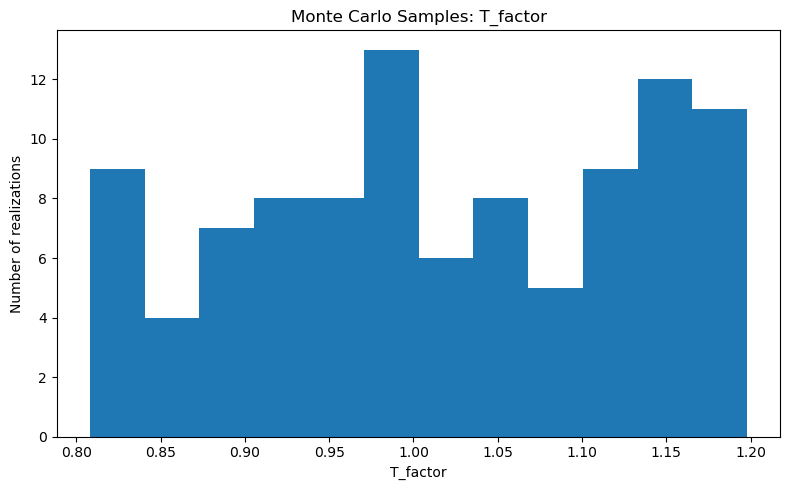

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sampled_T_factor_histogram.png


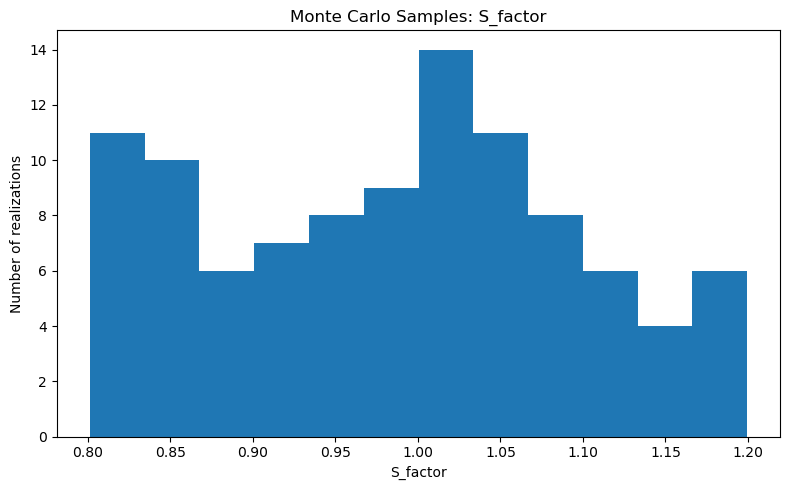

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sampled_S_factor_histogram.png


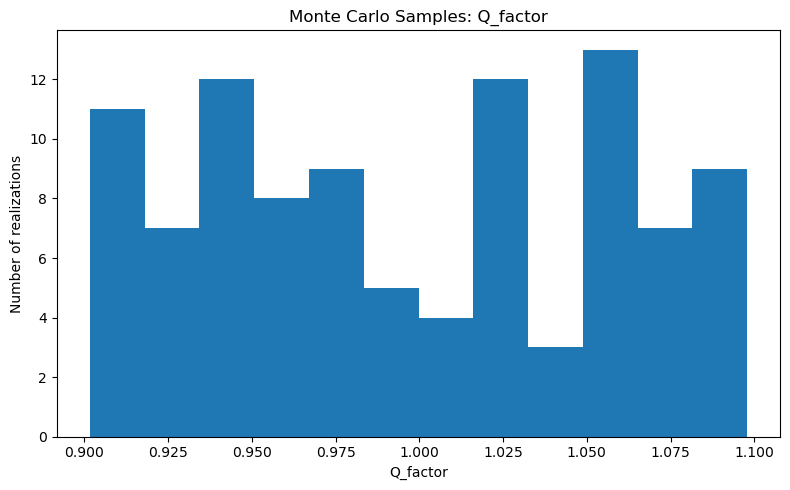

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sampled_Q_factor_histogram.png


In [25]:
for column in ["T_factor", "S_factor", "Q_factor"]:
    plt.figure(figsize=(8, 5))
    plt.hist(samples[column], bins=12)
    plt.xlabel(column)
    plt.ylabel("Number of realizations")
    plt.title(f"Monte Carlo Samples: {column}")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"sampled_{column}_histogram.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 8. Run Monte Carlo realizations

Each realization gets its own folder under:

```text
results/pycap_runs/monte_carlo_uncertainty/realizations/
```


In [26]:
OVERWRITE_REALIZATION_FOLDERS = True

realization_summary_rows = []
run_log_rows = []
selected_well_rows = []

# Track a manageable set of wells for detailed uncertainty summaries.
TOP_N_WELLS_TO_TRACK = 25
tracked_well_keys = set(
    baseline_dp
    .sort_values("Depletion_Potential", ascending=False)
    .head(TOP_N_WELLS_TO_TRACK)["well_key"]
)

for _, sample in samples.iterrows():
    realization = sample["realization"]
    T_factor = sample["T_factor"]
    S_factor = sample["S_factor"]
    Q_factor = sample["Q_factor"]

    print("=" * 90)
    print(f"Realization: {realization}")
    print(f"T_factor={T_factor:.4f}, S_factor={S_factor:.4f}, Q_factor={Q_factor:.4f}")

    realization_dir = REALIZATIONS_DIR / realization

    if realization_dir.exists():
        if OVERWRITE_REALIZATION_FOLDERS:
            shutil.rmtree(realization_dir)
        else:
            raise FileExistsError(
                f"Realization folder already exists: {realization_dir}. "
                "Set OVERWRITE_REALIZATION_FOLDERS = True to overwrite."
            )

    realization_dir.mkdir(parents=True, exist_ok=True)

    realization_config = apply_mc_sample(
        baseline_config,
        T_factor=T_factor,
        S_factor=S_factor,
        Q_factor=Q_factor,
    )

    realization_yaml_path = realization_dir / PYCAP_YAML_NAME
    write_yaml(realization_config, realization_yaml_path)

    timing = run_pycap_project(realization_dir, PYCAP_YAML_NAME)
    print(f"Elapsed time: {timing['elapsed']}")

    output_paths = get_output_paths(realization_dir)
    outputs_exist = {name: path.exists() for name, path in output_paths.items()}

    if not all(outputs_exist.values()):
        missing_outputs = [name for name, exists in outputs_exist.items() if not exists]
        raise FileNotFoundError(f"Realization {realization} is missing outputs: {missing_outputs}")

    dp_df = compute_depletion_potential(
        config=realization_config,
        base_stream_depletion_path=output_paths["base_stream_depletion"],
    )

    dp_values = dp_df["Depletion_Potential"].dropna()
    depl_values = dp_df["DEPL_cfs"].dropna()

    top_25_current = set(
        dp_df
        .sort_values("Depletion_Potential", ascending=False)
        .head(TOP_N_WELLS_TO_TRACK)["well_key"]
    )
    top_25_baseline = tracked_well_keys

    realization_summary_rows.append(
        {
            "realization": realization,
            "T_factor": T_factor,
            "S_factor": S_factor,
            "Q_factor": Q_factor,
            "T_value": sample["T_value"],
            "S_value": sample["S_value"],
            "n_wells": len(dp_df),
            "sum_individual_depletion_cfs": float(depl_values.sum()),
            "mean_individual_depletion_cfs": float(depl_values.mean()),
            "max_individual_depletion_cfs": float(depl_values.max()),
            "dp_min": float(dp_values.min()),
            "dp_mean": float(dp_values.mean()),
            "dp_median": float(dp_values.median()),
            "dp_max": float(dp_values.max()),
            "wells_dp_ge_0_001": int((dp_values >= 0.001).sum()),
            "wells_dp_ge_0_01": int((dp_values >= 0.01).sum()),
            "wells_dp_ge_0_05": int((dp_values >= 0.05).sum()),
            "wells_dp_ge_0_10": int((dp_values >= 0.10).sum()),
            "wells_dp_ge_0_20": int((dp_values >= 0.20).sum()),
            "wells_dp_ge_0_50": int((dp_values >= 0.50).sum()),
            "top_25_overlap_count": len(top_25_baseline.intersection(top_25_current)),
            "top_25_overlap_fraction": len(top_25_baseline.intersection(top_25_current)) / TOP_N_WELLS_TO_TRACK,
        }
    )

    tracked_rows = dp_df[dp_df["well_key"].isin(tracked_well_keys)].copy()
    tracked_rows.insert(0, "realization", realization)
    tracked_rows.insert(1, "T_factor", T_factor)
    tracked_rows.insert(2, "S_factor", S_factor)
    tracked_rows.insert(3, "Q_factor", Q_factor)
    selected_well_rows.append(tracked_rows)

    run_log_rows.append(
        {
            "realization": realization,
            "realization_folder": str(realization_dir.relative_to(PROJECT_ROOT)),
            "yaml_file": str(realization_yaml_path.relative_to(PROJECT_ROOT)),
            "start_time": timing["start_time"].isoformat(timespec="seconds"),
            "end_time": timing["end_time"].isoformat(timespec="seconds"),
            "elapsed": str(timing["elapsed"]),
            "outputs_exist": all(outputs_exist.values()),
        }
    )

print("=" * 90)
print("All Monte Carlo realizations completed.")


Realization: mc_000
T_factor=1.0647, S_factor=0.8012, Q_factor=0.9798
Writing report to /workspaces/Modeling-Uncertainties/results/pycap_runs/monte_carlo_uncertainty/realizations/mc_000/LPR_Redux.yml.import_report



Successfully parsed /workspaces/Modeling-Uncertainties/results/pycap_runs/monte_carlo_uncertainty/realizations/mc_000/LPR_Redux.yml (high five!)
*************************
Summary follows:

WELLS:
326 existing wells:
	466
	467
	490
	509
	602
	603
	798
	807
	850
	862
	1013
	1302
	1323
	1486
	1584
	1589
	1643
	1683
	1860
	2544
	2750
	2886
	3473
	3949
	4171
	23610
	23611
	23618
	23620
	23627
	23629
	23630
	23631
	23635
	23637
	23638
	23639
	23645
	23646
	23648
	23653
	23695
	23697
	23698
	23699
	23700
	23709
	23710
	23715
	23716
	23720
	23721
	23722
	23723
	23726
	23727
	23728
	23729
	23751
	23752
	23753
	23754
	23755
	23756
	23757
	23758
	23770
	23776
	23778
	23781
	23790
	23791
	23794
	23795
	23798
	23800
	23807
	23816
	23818
	23820
	23823
	23836
	23837
	23846
	23847
	23848


## 9. Combine and save Monte Carlo results

In [27]:
mc_summary = pd.DataFrame(realization_summary_rows)
mc_run_log = pd.DataFrame(run_log_rows)
tracked_well_results = pd.concat(selected_well_rows, ignore_index=True)

mc_summary_path = TABLES_DIR / "monte_carlo_summary.csv"
mc_run_log_path = TABLES_DIR / "monte_carlo_run_log.csv"
tracked_well_results_path = TABLES_DIR / "tracked_top25_well_results.csv"

mc_summary.to_csv(mc_summary_path, index=False)
mc_run_log.to_csv(mc_run_log_path, index=False)
tracked_well_results.to_csv(tracked_well_results_path, index=False)

print(f"Saved: {mc_summary_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {mc_run_log_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {tracked_well_results_path.relative_to(PROJECT_ROOT)}")

mc_summary.head()


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_summary.csv
Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_run_log.csv
Saved: results/pycap_runs/monte_carlo_uncertainty/tables/tracked_top25_well_results.csv


,realization,T_factor,S_factor,Q_factor,T_value,S_value,n_wells,sum_individual_depletion_cfs,mean_individual_depletion_cfs,max_individual_depletion_cfs,...,dp_median,dp_max,wells_dp_ge_0_001,wells_dp_ge_0_01,wells_dp_ge_0_05,wells_dp_ge_0_10,wells_dp_ge_0_20,wells_dp_ge_0_50,top_25_overlap_count,top_25_overlap_fraction
0,mc_000,1.064683,0.801212,0.979774,1809.960749,0.096145,327,5.794868,0.017721,0.445534,...,0.001026,0.603891,166,105,47,31,19,6,25,1.0
1,mc_001,1.009658,0.860983,0.908515,1716.419277,0.103318,327,5.050476,0.015445,0.387151,...,0.000664,0.585130,154,92,45,31,19,5,25,1.0
2,mc_002,0.937899,1.043805,0.942168,1594.428502,0.125257,327,4.563456,0.013956,0.361625,...,0.000235,0.543147,137,82,42,29,18,4,25,1.0
3,mc_003,0.948825,0.821411,1.022871,1613.002189,0.098569,327,5.643169,0.017257,0.432473,...,0.000628,0.582849,153,92,44,30,19,5,25,1.0
4,mc_004,0.911323,0.949259,1.080519,1549.248623,0.113911,327,5.419791,0.016574,0.424327,...,0.000307,0.553869,142,84,43,29,19,4,25,1.0


## 10. Monte Carlo output summary statistics

In [28]:
summary_metrics = [
    "sum_individual_depletion_cfs",
    "dp_mean",
    "dp_median",
    "dp_max",
    "wells_dp_ge_0_20",
    "top_25_overlap_fraction",
]

mc_output_stats = mc_summary[summary_metrics].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

mc_output_stats_path = TABLES_DIR / "monte_carlo_output_summary_statistics.csv"
mc_output_stats.to_csv(mc_output_stats_path)

print(f"Saved: {mc_output_stats_path.relative_to(PROJECT_ROOT)}")
mc_output_stats


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_output_summary_statistics.csv


,count,mean,std,min,5%,25%,50%,75%,95%,max
sum_individual_depletion_cfs,100.0,5.196290,0.491491,4.078940,4.455374,4.800603,5.195461,5.575803,5.960437,6.502087
dp_mean,100.0,0.032752,0.002702,0.026207,0.028842,0.031136,0.032578,0.034595,0.037717,0.038985
dp_median,100.0,0.000464,0.000269,0.000068,0.000158,0.000290,0.000398,0.000600,0.001053,0.001255
dp_max,100.0,0.564519,0.023229,0.502435,0.529575,0.551283,0.563970,0.580989,0.605101,0.614245
wells_dp_ge_0_20,100.0,18.550000,1.018763,15.000000,16.900000,19.000000,19.000000,19.000000,19.000000,19.000000
top_25_overlap_fraction,100.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 11. Compare Monte Carlo summary to baseline

This helps show where the baseline sits inside the uncertainty ensemble.


In [29]:
baseline_values = baseline_dp["Depletion_Potential"].dropna()
baseline_depl = baseline_dp["DEPL_cfs"].dropna()

baseline_summary = {
    "sum_individual_depletion_cfs": float(baseline_depl.sum()),
    "dp_mean": float(baseline_values.mean()),
    "dp_median": float(baseline_values.median()),
    "dp_max": float(baseline_values.max()),
    "wells_dp_ge_0_20": int((baseline_values >= 0.20).sum()),
}

baseline_comparison_rows = []

for metric, baseline_value in baseline_summary.items():
    ensemble_values = mc_summary[metric]
    percentile_rank = float((ensemble_values <= baseline_value).mean() * 100)

    baseline_comparison_rows.append(
        {
            "metric": metric,
            "baseline_value": baseline_value,
            "ensemble_min": float(ensemble_values.min()),
            "ensemble_mean": float(ensemble_values.mean()),
            "ensemble_median": float(ensemble_values.median()),
            "ensemble_max": float(ensemble_values.max()),
            "baseline_percentile_rank": percentile_rank,
        }
    )

baseline_vs_mc = pd.DataFrame(baseline_comparison_rows)

baseline_vs_mc_path = TABLES_DIR / "baseline_vs_monte_carlo_summary.csv"
baseline_vs_mc.to_csv(baseline_vs_mc_path, index=False)

print(f"Saved: {baseline_vs_mc_path.relative_to(PROJECT_ROOT)}")
baseline_vs_mc


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/baseline_vs_monte_carlo_summary.csv


,metric,baseline_value,ensemble_min,ensemble_mean,ensemble_median,ensemble_max,baseline_percentile_rank
0,sum_individual_depletion_cfs,5.123893,4.078940,5.196290,5.195461,6.502087,48.0
1,dp_mean,0.032152,0.026207,0.032752,0.032578,0.038985,45.0
2,dp_median,0.000362,0.000068,0.000464,0.000398,0.001255,45.0
3,dp_max,0.560296,0.502435,0.564519,0.563970,0.614245,45.0
4,wells_dp_ge_0_20,19.000000,15.000000,18.550000,19.000000,19.000000,100.0


## 12. Correlation screening

This is a simple first-pass screen for which sampled factors are most associated with output changes.

This is not a formal sensitivity analysis, but it is useful for learning.


In [30]:
correlation_columns = [
    "T_factor",
    "S_factor",
    "Q_factor",
    "sum_individual_depletion_cfs",
    "dp_mean",
    "dp_max",
    "wells_dp_ge_0_20",
]

correlation_table = mc_summary[correlation_columns].corr()

correlation_path = TABLES_DIR / "monte_carlo_correlation_screen.csv"
correlation_table.to_csv(correlation_path)

print(f"Saved: {correlation_path.relative_to(PROJECT_ROOT)}")
correlation_table


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_correlation_screen.csv


,T_factor,S_factor,Q_factor,sum_individual_depletion_cfs,dp_mean,dp_max,wells_dp_ge_0_20
T_factor,1.000000,0.144632,-0.082513,0.480899,0.659727,0.663078,0.469788
S_factor,0.144632,1.000000,-0.029396,-0.535602,-0.644881,-0.642521,-0.452110
Q_factor,-0.082513,-0.029396,1.000000,0.593004,-0.046618,-0.044992,-0.031923
sum_individual_depletion_cfs,0.480899,-0.535602,0.593004,1.000000,0.775438,0.775856,0.536445
dp_mean,0.659727,-0.644881,-0.046618,0.775438,1.000000,0.998274,0.680241
dp_max,0.663078,-0.642521,-0.044992,0.775856,0.998274,1.000000,0.716974
wells_dp_ge_0_20,0.469788,-0.452110,-0.031923,0.536445,0.680241,0.716974,1.000000


## 13. Plot Monte Carlo distributions

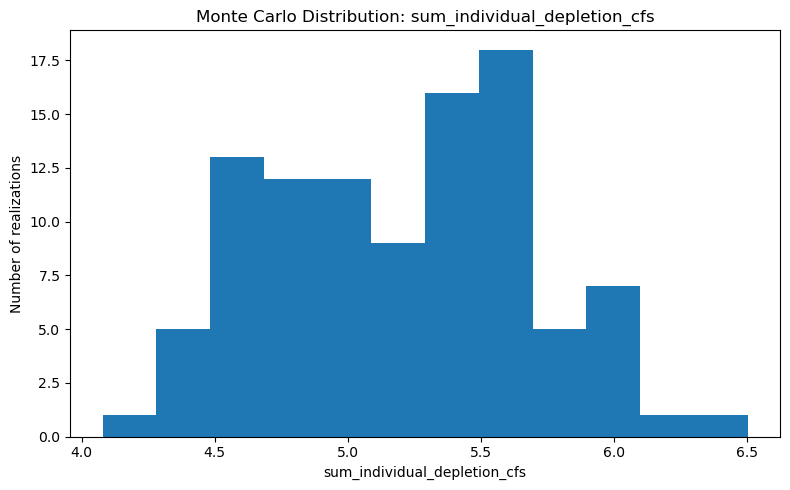

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sum_individual_depletion_cfs_histogram.png


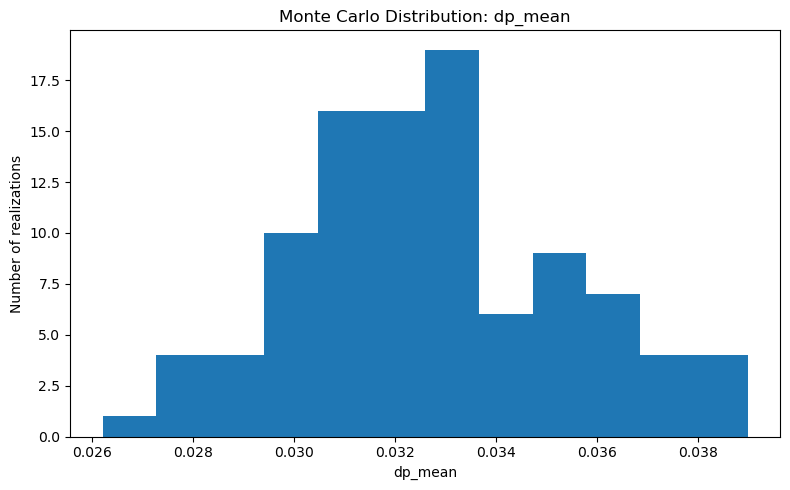

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/dp_mean_histogram.png


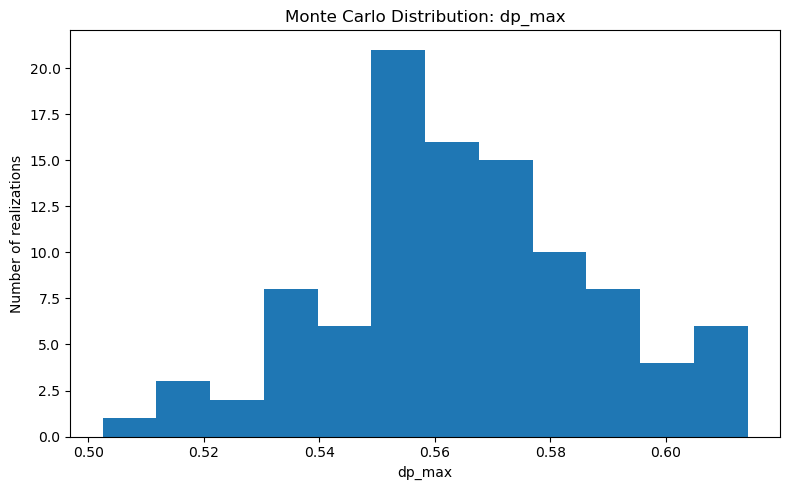

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/dp_max_histogram.png


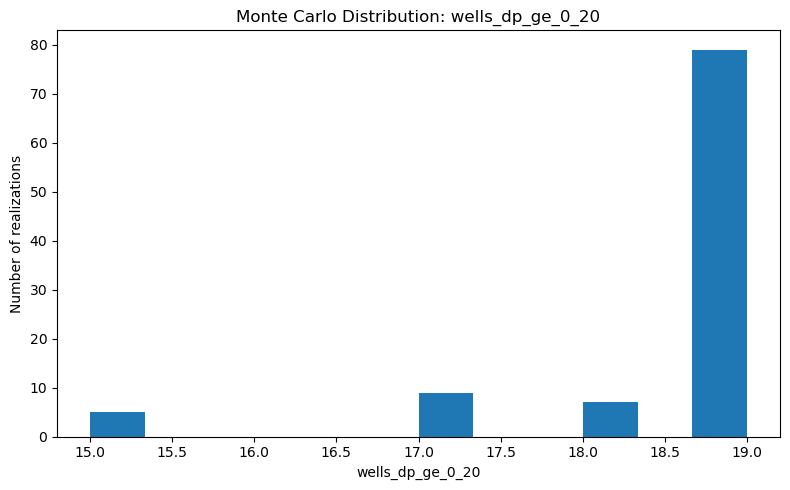

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/wells_dp_ge_0_20_histogram.png


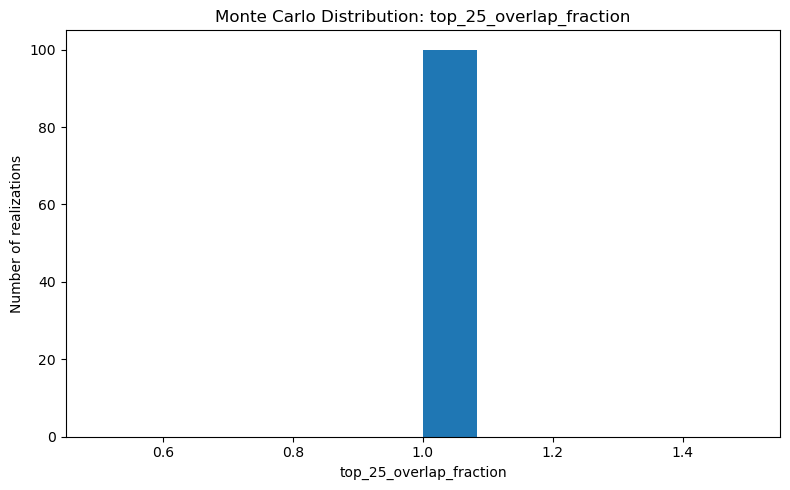

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/top_25_overlap_fraction_histogram.png


In [31]:
distribution_metrics = [
    "sum_individual_depletion_cfs",
    "dp_mean",
    "dp_max",
    "wells_dp_ge_0_20",
    "top_25_overlap_fraction",
]

for metric in distribution_metrics:
    plt.figure(figsize=(8, 5))
    plt.hist(mc_summary[metric].dropna(), bins=12)
    plt.xlabel(metric)
    plt.ylabel("Number of realizations")
    plt.title(f"Monte Carlo Distribution: {metric}")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"{metric}_histogram.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 14. Plot sampled factors versus key outputs

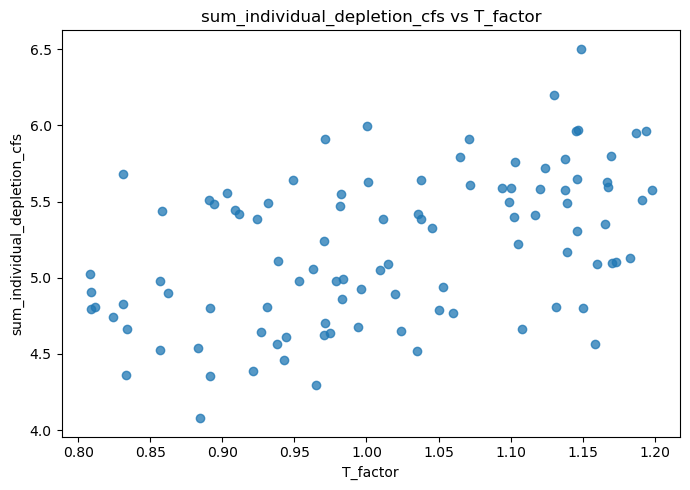

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sum_individual_depletion_cfs_vs_T_factor.png


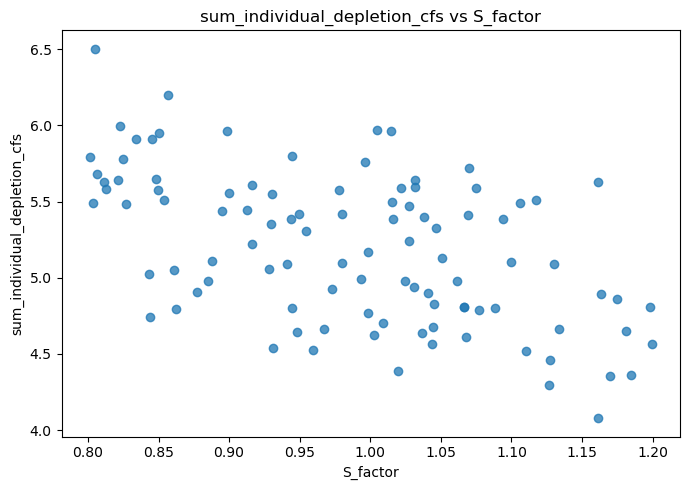

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sum_individual_depletion_cfs_vs_S_factor.png


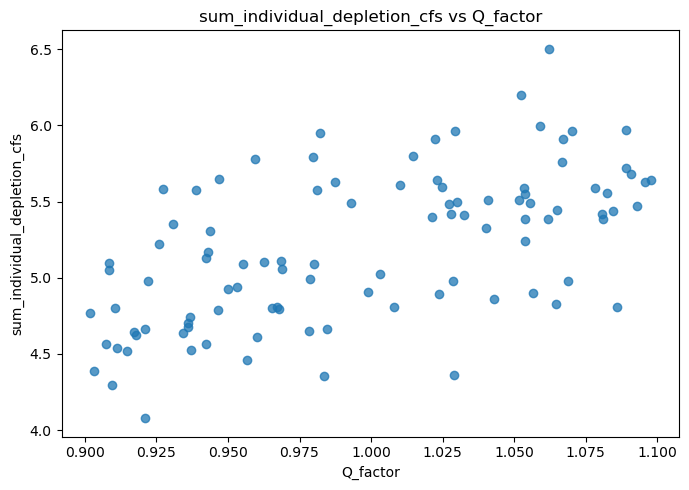

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/sum_individual_depletion_cfs_vs_Q_factor.png


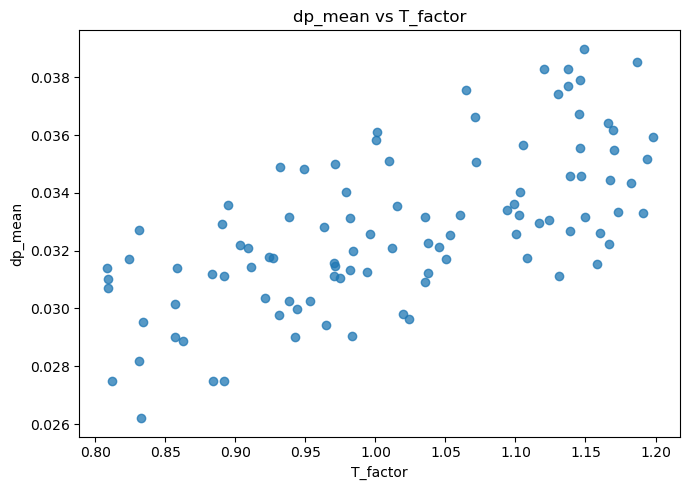

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/dp_mean_vs_T_factor.png


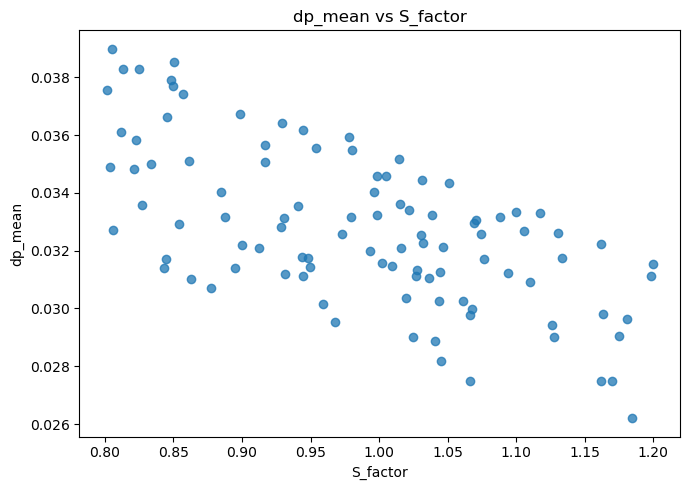

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/dp_mean_vs_S_factor.png


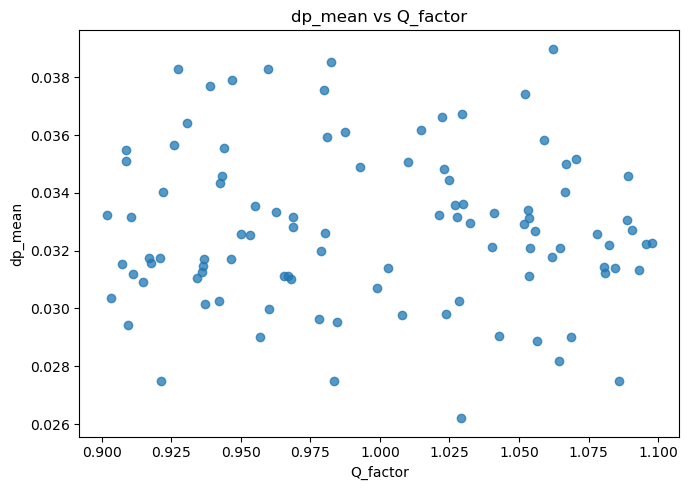

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/dp_mean_vs_Q_factor.png


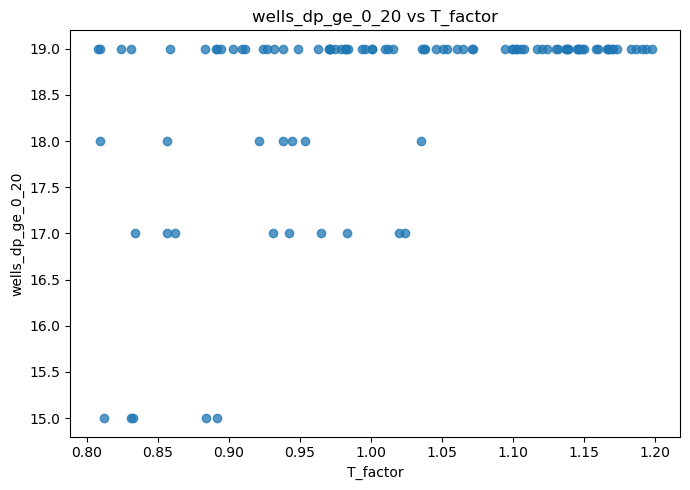

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/wells_dp_ge_0_20_vs_T_factor.png


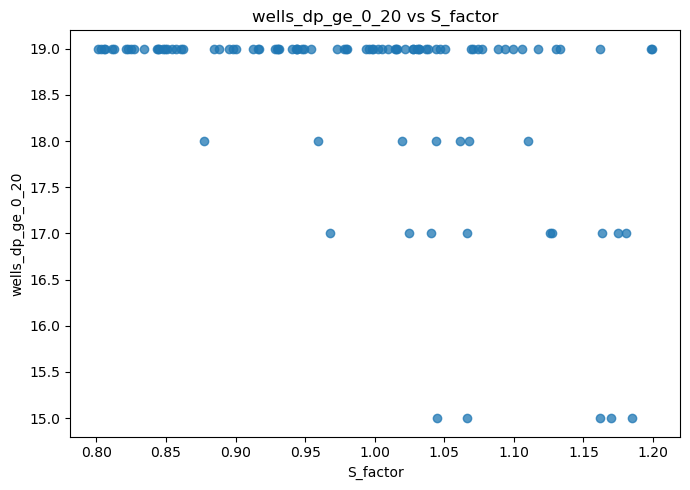

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/wells_dp_ge_0_20_vs_S_factor.png


In [32]:
factor_output_pairs = [
    ("T_factor", "sum_individual_depletion_cfs"),
    ("S_factor", "sum_individual_depletion_cfs"),
    ("Q_factor", "sum_individual_depletion_cfs"),
    ("T_factor", "dp_mean"),
    ("S_factor", "dp_mean"),
    ("Q_factor", "dp_mean"),
    ("T_factor", "wells_dp_ge_0_20"),
    ("S_factor", "wells_dp_ge_0_20"),
]

for x_col, y_col in factor_output_pairs:
    plt.figure(figsize=(7, 5))
    plt.scatter(mc_summary[x_col], mc_summary[y_col], alpha=0.75)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"{y_col}_vs_{x_col}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 15. Track uncertainty for baseline top 25 wells

This summarizes the DP range for the top 25 baseline wells across all Monte Carlo realizations.


In [33]:
top25_well_uncertainty = (
    tracked_well_results
    .groupby(["well_key", "name"], as_index=False)
    .agg(
        q_gpm_mean=("Q_gpm", "mean"),
        depl_cfs_min=("DEPL_cfs", "min"),
        depl_cfs_mean=("DEPL_cfs", "mean"),
        depl_cfs_max=("DEPL_cfs", "max"),
        dp_min=("Depletion_Potential", "min"),
        dp_mean=("Depletion_Potential", "mean"),
        dp_median=("Depletion_Potential", "median"),
        dp_max=("Depletion_Potential", "max"),
        dp_range=("Depletion_Potential", lambda x: x.max() - x.min()),
        fraction_dp_ge_0_20=("Depletion_Potential", lambda x: float((x >= 0.20).mean())),
    )
    .sort_values("dp_mean", ascending=False)
)

top25_well_uncertainty_path = TABLES_DIR / "top25_well_uncertainty_summary.csv"
top25_well_uncertainty.to_csv(top25_well_uncertainty_path, index=False)

print(f"Saved: {top25_well_uncertainty_path.relative_to(PROJECT_ROOT)}")
top25_well_uncertainty


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/top25_well_uncertainty_summary.csv


,well_key,name,q_gpm_mean,depl_cfs_min,depl_cfs_mean,depl_cfs_max,dp_min,dp_mean,dp_median,dp_max,dp_range,fraction_dp_ge_0_20
1,well_23627,23627,275.802293,0.292712,0.346853,0.401918,0.502435,0.564519,0.563970,0.614245,0.111809,1.00
17,well_68529,68529,219.345115,0.232329,0.275342,0.319106,0.501394,0.563475,0.562914,0.613208,0.111814,1.00
3,well_23653,23653,262.934845,0.278260,0.327908,0.378194,0.501881,0.559799,0.559374,0.606273,0.104392,1.00
13,well_466,466,315.102873,0.330567,0.384255,0.437223,0.499306,0.547379,0.547131,0.584860,0.085554,1.00
9,well_23934,23934,369.664846,0.332920,0.400740,0.471552,0.424674,0.486625,0.485996,0.537679,0.113005,1.00
18,well_69049,69049,37.505122,0.032423,0.039343,0.046697,0.406855,0.470894,0.470107,0.524811,0.117956,1.00
14,well_467,467,296.150817,0.240872,0.289021,0.337685,0.383325,0.438078,0.437830,0.480619,0.097294,1.00
21,well_71109,71109,14.962150,0.011620,0.014175,0.016793,0.364002,0.425291,0.424978,0.473075,0.109072,1.00
12,well_24323,24323,205.879180,0.130881,0.164117,0.201543,0.296811,0.357853,0.356644,0.412626,0.115815,1.00
22,well_71110,71110,12.967196,0.007409,0.009309,0.011324,0.265717,0.322252,0.321743,0.368102,0.102385,1.00


## 16. Plot top-well DP uncertainty ranges

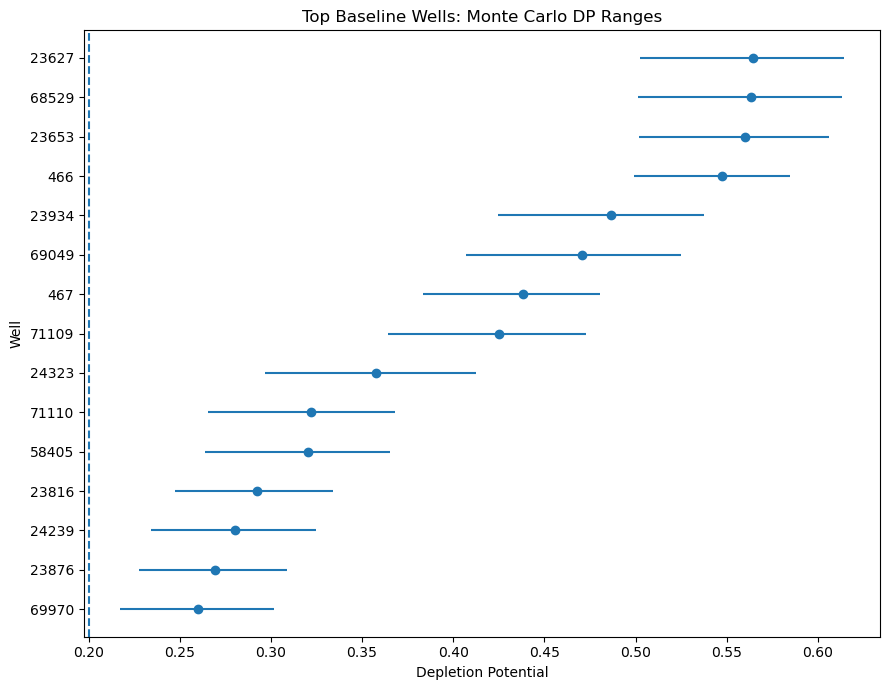

Saved: results/pycap_runs/monte_carlo_uncertainty/figures/top_well_dp_uncertainty_ranges.png


In [34]:
plot_top = top25_well_uncertainty.head(15).copy()
plot_top = plot_top.sort_values("dp_mean")

plt.figure(figsize=(9, 7))
plt.errorbar(
    plot_top["dp_mean"],
    plot_top["name"].astype(str),
    xerr=[
        plot_top["dp_mean"] - plot_top["dp_min"],
        plot_top["dp_max"] - plot_top["dp_mean"],
    ],
    fmt="o",
)
plt.axvline(0.20, linestyle="--")
plt.xlabel("Depletion Potential")
plt.ylabel("Well")
plt.title("Top Baseline Wells: Monte Carlo DP Ranges")
plt.tight_layout()

fig_path = FIGURES_DIR / "top_well_dp_uncertainty_ranges.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 17. First-pass interpretation table

In [35]:
interpretation_rows = []

for metric in ["sum_individual_depletion_cfs", "dp_mean", "dp_max", "wells_dp_ge_0_20"]:
    row = baseline_vs_mc[baseline_vs_mc["metric"] == metric].iloc[0]

    interpretation_rows.append(
        {
            "metric": metric,
            "baseline_value": row["baseline_value"],
            "ensemble_min": row["ensemble_min"],
            "ensemble_median": row["ensemble_median"],
            "ensemble_max": row["ensemble_max"],
            "baseline_percentile_rank": row["baseline_percentile_rank"],
            "interpretation_note": (
                "If the baseline percentile is near 50, the baseline is near the center of the sampled ensemble. "
                "If it is near 0 or 100, the baseline is near an edge of the sampled uncertainty range."
            ),
        }
    )

interpretation_table = pd.DataFrame(interpretation_rows)

interpretation_path = TABLES_DIR / "monte_carlo_first_pass_interpretation.csv"
interpretation_table.to_csv(interpretation_path, index=False)

print(f"Saved: {interpretation_path.relative_to(PROJECT_ROOT)}")
interpretation_table


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_first_pass_interpretation.csv


,metric,baseline_value,ensemble_min,ensemble_median,ensemble_max,baseline_percentile_rank,interpretation_note
0,sum_individual_depletion_cfs,5.123893,4.078940,5.195461,6.502087,48.0,"If the baseline percentile is near 50, the bas..."
1,dp_mean,0.032152,0.026207,0.032578,0.038985,45.0,"If the baseline percentile is near 50, the bas..."
2,dp_max,0.560296,0.502435,0.563970,0.614245,45.0,"If the baseline percentile is near 50, the bas..."
3,wells_dp_ge_0_20,19.000000,15.000000,19.000000,19.000000,100.0,"If the baseline percentile is near 50, the bas..."


## 18. Save notebook summary

In [36]:
notebook_summary = pd.DataFrame(
    [
        {"item": "project_root", "value": str(PROJECT_ROOT)},
        {"item": "baseline_yaml", "value": str(PYCAP_YAML_PATH.relative_to(PROJECT_ROOT))},
        {"item": "monte_carlo_folder", "value": str(MC_DIR.relative_to(PROJECT_ROOT))},
        {"item": "random_seed", "value": RANDOM_SEED},
        {"item": "number_of_realizations", "value": N_REALIZATIONS},
        {"item": "T_factor_low", "value": T_FACTOR_LOW},
        {"item": "T_factor_high", "value": T_FACTOR_HIGH},
        {"item": "S_factor_low", "value": S_FACTOR_LOW},
        {"item": "S_factor_high", "value": S_FACTOR_HIGH},
        {"item": "Q_factor_low", "value": Q_FACTOR_LOW},
        {"item": "Q_factor_high", "value": Q_FACTOR_HIGH},
        {"item": "baseline_T", "value": baseline_config["project_properties"].get("T")},
        {"item": "baseline_S", "value": baseline_config["project_properties"].get("S")},
        {"item": "number_of_wells", "value": len(baseline_wells_df)},
        {"item": "tracked_top_wells", "value": TOP_N_WELLS_TO_TRACK},
        {"item": "run_timestamp", "value": datetime.now().isoformat(timespec="seconds")},
    ]
)

notebook_summary_path = TABLES_DIR / "monte_carlo_notebook_summary.csv"
notebook_summary.to_csv(notebook_summary_path, index=False)

print(f"Saved: {notebook_summary_path.relative_to(PROJECT_ROOT)}")
notebook_summary


Saved: results/pycap_runs/monte_carlo_uncertainty/tables/monte_carlo_notebook_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,baseline_yaml,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml
2,monte_carlo_folder,results/pycap_runs/monte_carlo_uncertainty
3,random_seed,564
4,number_of_realizations,100
5,T_factor_low,0.8
6,T_factor_high,1.2
7,S_factor_low,0.8
8,S_factor_high,1.2
9,Q_factor_low,0.9


## 19. Final interpretation

This notebook is the first Monte Carlo-style uncertainty workflow.

Main questions to answer after running it:

1. How wide is the distribution of total individual LPR depletion?
2. How much does the number of wells above `DP = 0.20` vary?
3. Are the baseline top wells stable across sampled uncertainty?
4. Which sampled factor is most correlated with `dp_mean`, `dp_max`, or total depletion?
5. Is the baseline near the center or edge of the sampled ensemble?

Good next steps after this notebook:

```text
06_compare_uncertainty_results_to_pareto_members.ipynb
```

or

```text
06_pycap_uncertainty_report_figures.ipynb
```

The first option connects uncertainty to decision-making. The second option creates cleaner figures for your report or presentation.
